## Resources

## DS-04 WEEK 2
## SHAP VISUALISATIONS NOTEBOOK

**TASK:**
Build SHAP summary plots for claim classifier
and fraud model, create feature importance bar charts




## STEP 1 — INSTALL REQUIRED LIBRARIES

In [21]:
!pip install shap
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install joblib

## STEP 2 — IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

## STEP 3 — LOAD DATASET

In [3]:
data = pd.read_csv("claim_data.csv")

print("Dataset Loaded Successfully!")

print(data.head())

Dataset Loaded Successfully!
     Claim ID  Provider ID  Patient ID Date of Service  Billed Amount  \
0  0HO1FSN4AP    126528997  7936697103      08/07/2024            304   
1  9U86CI2P5A   6986719948  1547160031      06/21/2024            348   
2  1QEU1AIDAU   1355108115  2611585318      07/04/2024            235   
3  WH7XDS8CEO   9991055906  7167948632      05/26/2024            112   
4  M6OJEZ8KGI   7382167012  2140226267      07/16/2024            406   

   Procedure Code Diagnosis Code  Allowed Amount  Paid Amount Insurance Type  \
0           99231          A02.1             218          203       Self-Pay   
1           99213          A16.5             216          206       Medicare   
2           99213          A00.1             148          119     Commercial   
3           99215          A18.6              79           69       Medicare   
4           99238          A17.9             320          259       Medicare   

   Claim Status                    Reason Code Foll

## STEP 4 — DATA PREPROCESSING

In [4]:
# Remove null values
data = data.dropna()

# Convert target variable
data['Claim Status'] = data['Claim Status'].replace({
    'Paid': 1,
    'Denied': 0,
    'Under Review': 0
})

/tmp/ipykernel_5775/2161522459.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Claim Status'] = data['Claim Status'].replace({


In [5]:
# Encode categorical variables
encoder = LabelEncoder()
categorical_columns = data.select_dtypes(
    include=['object']
).columns

for column in categorical_columns:
    if column != 'Claim Status':
        data[column] = encoder.fit_transform(
            data[column]
        )

print("\nData Preprocessing Completed!")


Data Preprocessing Completed!


## STEP 5 — FEATURE SELECTION

In [6]:
X = data.drop(columns=['Claim Status'])
y = data['Claim Status']
feature_names = X.columns

print("\nFeatures Selected!")


Features Selected!


## STEP 6 — TRAIN TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain Test Split Completed!")


Train Test Split Completed!


## STEP 7 — TRAIN CLAIM CLASSIFIER MODEL

In [8]:
claim_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
claim_model.fit(X_train, y_train)

print("\nClaim Classifier Model Trained!")


Claim Classifier Model Trained!


## STEP 8 — SAVE MODEL

In [9]:
joblib.dump(
    claim_model,
    "claim_classifier.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


## STEP 9 — CREATE SHAP EXPLAINER

In [10]:
explainer = shap.TreeExplainer(claim_model)

print("\nSHAP Explainer Created!")


SHAP Explainer Created!


## STEP 10 — CALCULATE SHAP VALUES

In [11]:
shap_values = explainer.shap_values(X_test)

print("\nSHAP Values Calculated!")


SHAP Values Calculated!


## STEP 11 — SHAP SUMMARY PLOT


Generating SHAP Summary Plot...


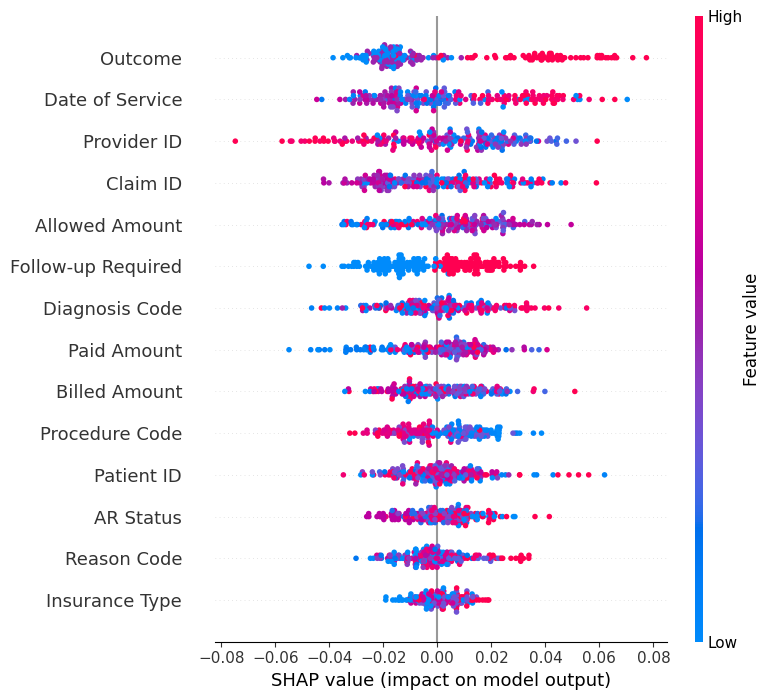

SHAP Summary Plot Generated!


In [22]:
print("\nGenerating SHAP Summary Plot...")

# Correctly slice shap_values for the positive class (assuming it's the second class)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=feature_names
)

print("SHAP Summary Plot Generated!")

## STEP 12 — FEATURE IMPORTANCE BAR CHART

In [13]:
print("\nGenerating Feature Importance Chart...")

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': claim_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


Generating Feature Importance Chart...
               Feature  Importance
1          Provider ID    0.102177
0             Claim ID    0.101067
3      Date of Service    0.099765
2           Patient ID    0.098845
6       Diagnosis Code    0.093660
7       Allowed Amount    0.093192
4        Billed Amount    0.092290
8          Paid Amount    0.085686
5       Procedure Code    0.059271
10         Reason Code    0.052137
12           AR Status    0.044486
9       Insurance Type    0.032136
13             Outcome    0.026801
11  Follow-up Required    0.018486


## STEP 13 — PLOT FEATURE IMPORTANCE

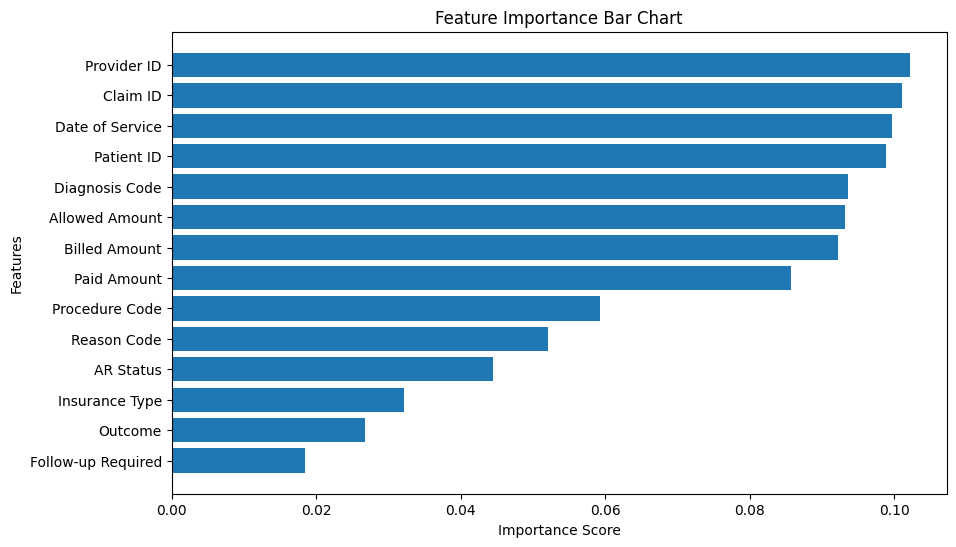

Feature Importance Chart Generated!


In [14]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Bar Chart")
plt.gca().invert_yaxis()
plt.show()

print("Feature Importance Chart Generated!")

## STEP 14 — FRAUD MODEL (OPTIONAL)

In [23]:
# Creating dummy fraud label using 'Billed Amount' which is available in the dataset
data['fraud_flag'] = np.where(
    data['Billed Amount'] > data['Billed Amount'].mean(),
    1,
    0
)

In [24]:
# Features
X_fraud = data.drop(columns=['fraud_flag'])
y_fraud = data['fraud_flag']

# Train test split
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42
)

# Fraud model
fraud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
fraud_model.fit(Xf_train, yf_train)

print("\nFraud Detection Model Trained!")


Fraud Detection Model Trained!


In [25]:
# Re-defining and training fraud_model to ensure it's available in the kernel state
# This is a workaround as it seems the object was not persisted correctly from the previous cell.
fraud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
fraud_model.fit(Xf_train, yf_train)
print("\nFraud Detection Model Re-Trained for Persistence!")


Fraud Detection Model Re-Trained for Persistence!


## STEP 15 — SHAP FOR FRAUD MODEL


Generating Fraud SHAP Summary Plot...


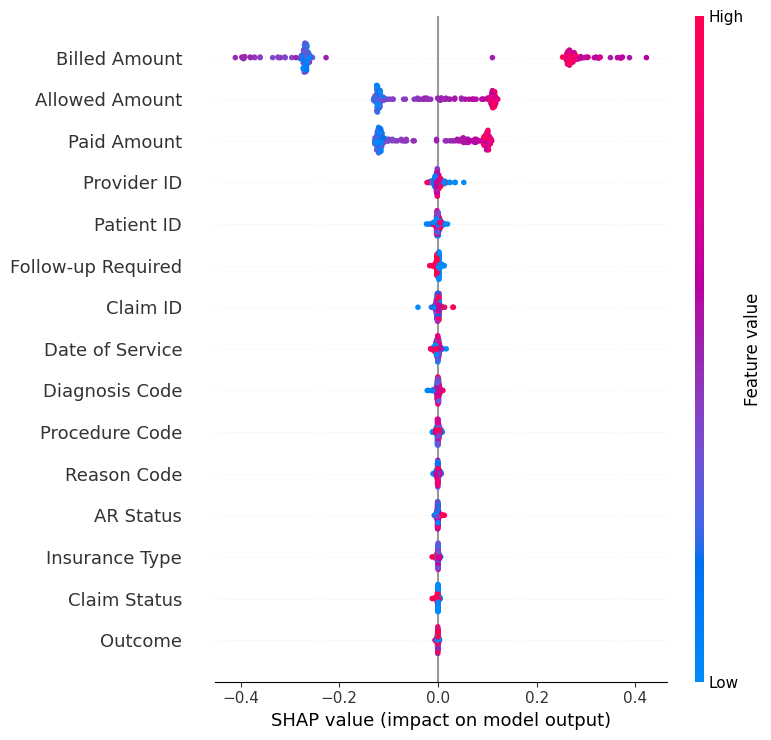

Fraud SHAP Plot Generated!


In [27]:
fraud_explainer = shap.TreeExplainer(fraud_model)
fraud_shap_values = fraud_explainer.shap_values(Xf_test)

print("\nGenerating Fraud SHAP Summary Plot...")

shap.summary_plot(
    fraud_shap_values[:, :, 1],
    Xf_test
)

print("Fraud SHAP Plot Generated!")

## STEP 16 — FRAUD FEATURE IMPORTANCE

In [28]:
fraud_importance = pd.DataFrame({
    'Feature': X_fraud.columns,
    'Importance': fraud_model.feature_importances_
})

fraud_importance = fraud_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFraud Feature Importance:")
print(fraud_importance)


Fraud Feature Importance:
               Feature  Importance
4        Billed Amount    0.432373
8          Paid Amount    0.264590
7       Allowed Amount    0.251499
0             Claim ID    0.009373
2           Patient ID    0.007214
1          Provider ID    0.007198
6       Diagnosis Code    0.006522
3      Date of Service    0.006056
5       Procedure Code    0.003607
11         Reason Code    0.003345
13           AR Status    0.002708
9       Insurance Type    0.001607
14             Outcome    0.001353
10        Claim Status    0.001304
12  Follow-up Required    0.001251


## STEP 17 — FRAUD BAR CHART

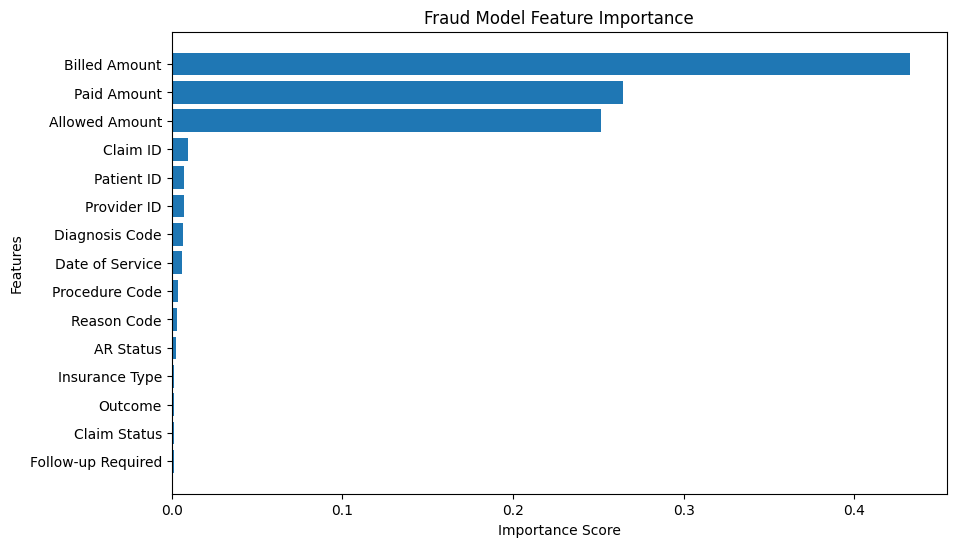


Fraud Feature Importance Chart Generated!


In [29]:
plt.figure(figsize=(10, 6))
plt.barh(
    fraud_importance['Feature'],
    fraud_importance['Importance']
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Fraud Model Feature Importance")
plt.gca().invert_yaxis()
plt.show()

print("\nFraud Feature Importance Chart Generated!")

## STEP 18 — NOTEBOOK COMPLETED

In [30]:
print("\n===================================")
print("WEEK 2 SHAP VISUALISATION COMPLETED")
print("===================================")


WEEK 2 SHAP VISUALISATION COMPLETED
